<a href="https://colab.research.google.com/github/KhoirotunNisa25/PCVK_Ganjil_2025/blob/main/Week5_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modul 5: Histogram

## Praktikum D1: Percobaan Histogram

### Langkah 1: Import folder

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Langkah 2: Import Library

In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

### Langkah 3: Membuat histogram citra

<BarContainer object of 256 artists>

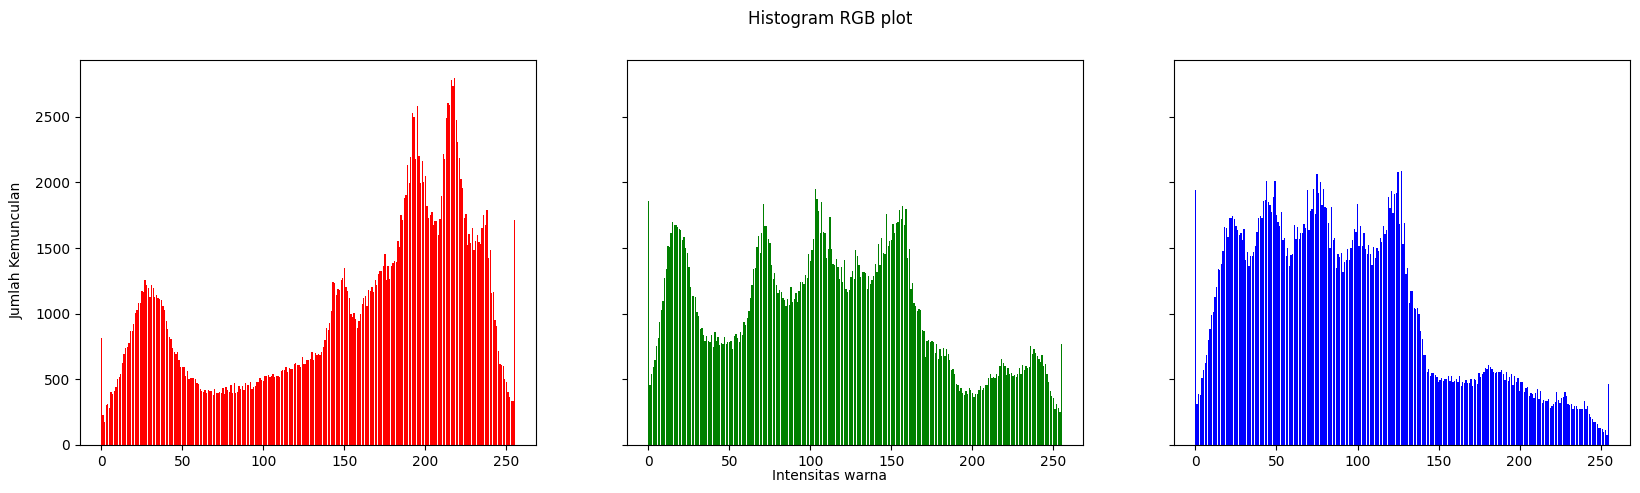

In [3]:
# membuat historam image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

## Pertanyaan Praktikum D1

1. BuatlaBuatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?

<BarContainer object of 256 artists>

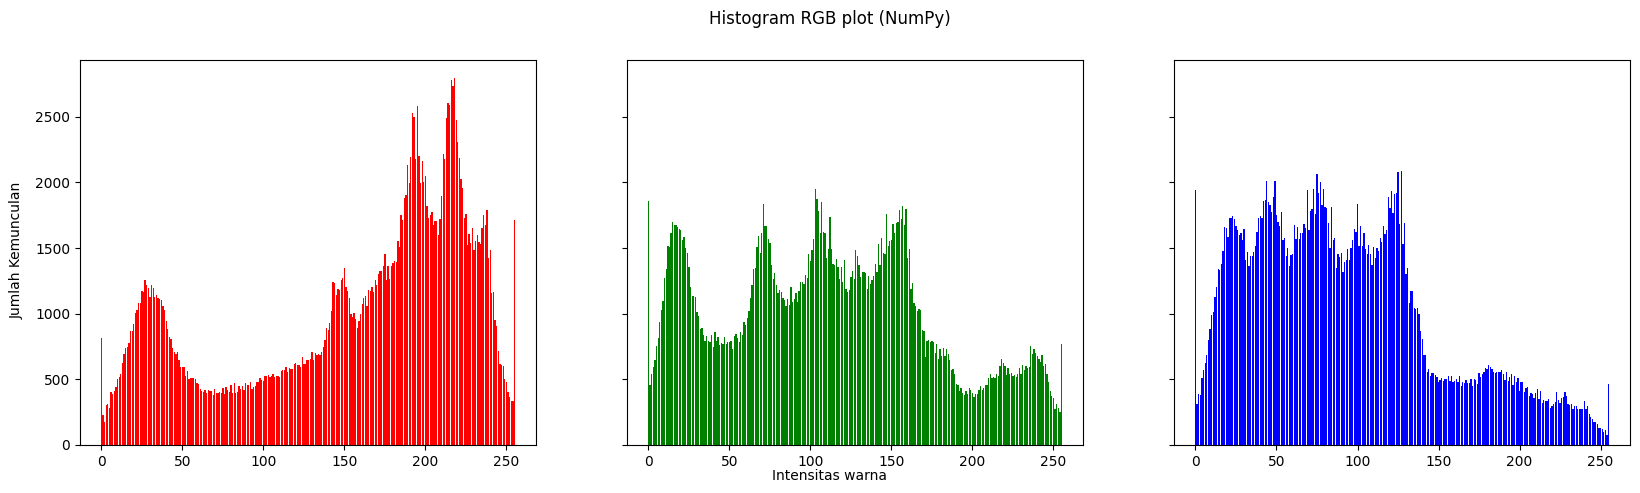

In [6]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Histogram dengan NumPy
red_np, bins_r = np.histogram(img[:,:,0], bins=256, range=(0,256))
green_np, bins_g = np.histogram(img[:,:,1], bins=256, range=(0,256))
blue_np, bins_b = np.histogram(img[:,:,2], bins=256, range=(0,256))

# Plot hasil NumPy
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot (NumPy)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas warna', ha='center')
axs[0].bar(names, red_np, color='red')
axs[1].bar(names, green_np, color='green')
axs[2].bar(names, blue_np, color='blue')

2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg.Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung gelap, terang, atau kontras rendah.

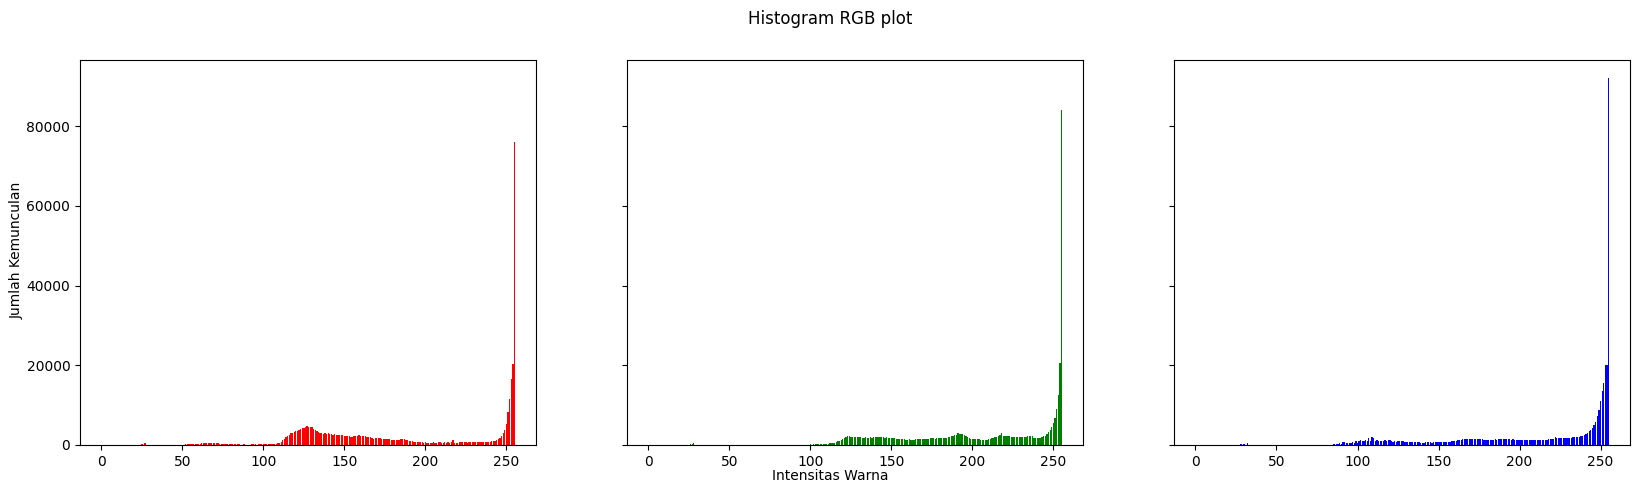

In [23]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/ktm_lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red   = [0]* 256
green = [0]* 256
blue  = [0]* 256

for y in range(0, height) :
  for x in range(0, width) :
    red   [img[y][x][0]] += 1
    green [img[y][x][1]] += 1
    blue  [img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

## Praktikum D2: Percobaan Histogram Equalization

### Langkah 1: Membuat histogram citra seperti output histogram equalisation

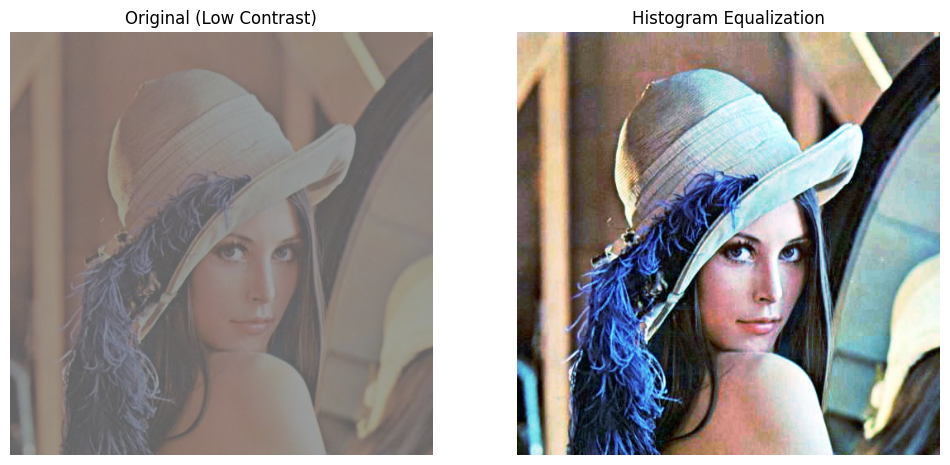

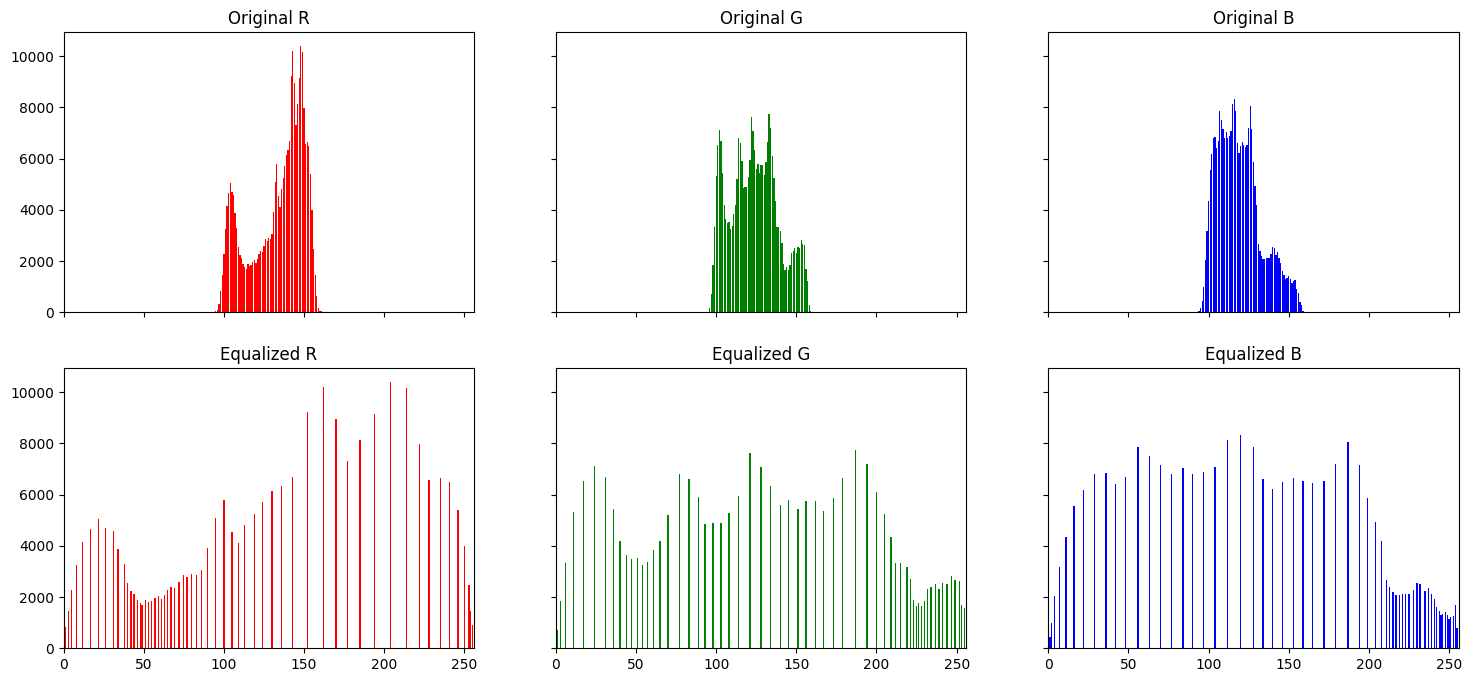

In [15]:
# Load gambar lena low contrast (RGB)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel
r, g, b = cv.split(img)

# Equalization per channel
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan kembali
img_eq = cv.merge((r_eq, g_eq, b_eq))

# Plot hasil citra
fig, axs = plt.subplots(1, 2, figsize=(12,6))
axs[0].imshow(img)
axs[0].set_title("Original (Low Contrast)")
axs[0].axis("off")

axs[1].imshow(img_eq)
axs[1].set_title("Histogram Equalization")
axs[1].axis("off")
plt.show()

# Histogram sebelum dan sesudah (full bar)
colors = ('r','g','b')
names = np.arange(256)

fig, axs = plt.subplots(2,3, figsize=(18,8), sharex=True, sharey=True)

for i, col in enumerate(colors):
    # Histogram sebelum
    hist_orig = cv.calcHist([img],[i],None,[256],[0,256]).flatten()
    axs[0,i].bar(names, hist_orig, color=col)
    axs[0,i].set_title(f"Original {col.upper()}")
    axs[0,i].set_xlim([0,256])

    # Histogram sesudah
    hist_eq = cv.calcHist([img_eq],[i],None,[256],[0,256]).flatten()
    axs[1,i].bar(names, hist_eq, color=col)
    axs[1,i].set_title(f"Equalized {col.upper()}")
    axs[1,i].set_xlim([0,256])

plt.show()


### Langkah 2: Membuat histogram meggunakan library equalizeHist

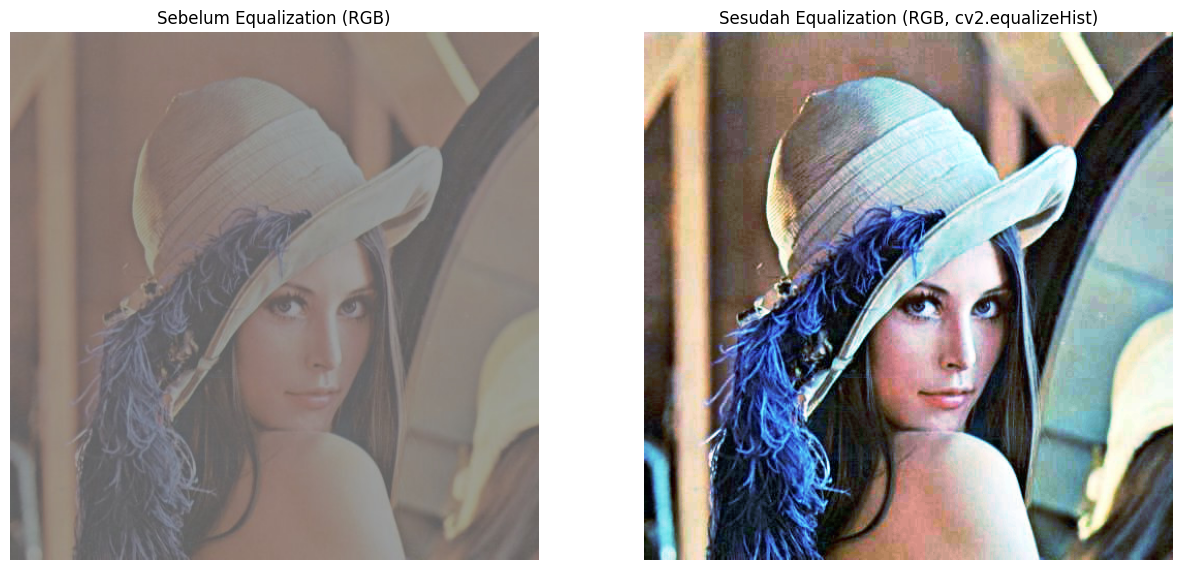

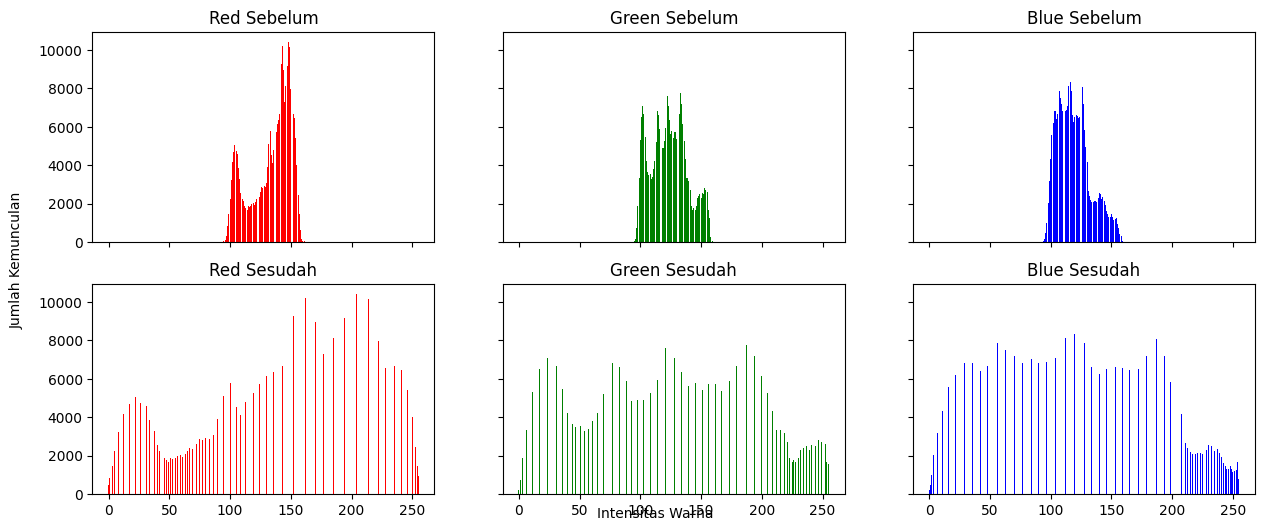

In [16]:
# --- Baca gambar ---
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# --- Split channel ---
r, g, b = cv.split(img)

# --- Equalization per channel ---
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# --- Merge hasil equalization ---
img_eq = cv.merge((r_eq, g_eq, b_eq))

# --- Histogram sebelum equalization ---
names = np.arange(256)
red = cv.calcHist([img],[0],None,[256],[0,256]).flatten()
green = cv.calcHist([img],[1],None,[256],[0,256]).flatten()
blue = cv.calcHist([img],[2],None,[256],[0,256]).flatten()

# --- Histogram sesudah equalization ---
red_eq = cv.calcHist([img_eq],[0],None,[256],[0,256]).flatten()
green_eq = cv.calcHist([img_eq],[1],None,[256],[0,256]).flatten()
blue_eq = cv.calcHist([img_eq],[2],None,[256],[0,256]).flatten()

# --- Tampilkan gambar ---
fig, (ax1, ax2) = plt.subplots(1,2, figsize=[15,7])
ax1.imshow(img)
ax1.set_title("Sebelum Equalization (RGB)")
ax1.axis("off")
ax2.imshow(img_eq)
ax2.set_title("Sesudah Equalization (RGB, cv2.equalizeHist)")
ax2.axis("off")
plt.show()

# --- Tampilkan histogram dengan bar ---
fig, axs = plt.subplots(2, 3, figsize=[15,6], sharex=True, sharey=True)
fig.text(0.07, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.07, 'Intensitas Warna', ha='center')

# Histogram sebelum
axs[0,0].bar(names, red, color='red');   axs[0,0].set_title("Red Sebelum")
axs[0,1].bar(names, green, color='green'); axs[0,1].set_title("Green Sebelum")
axs[0,2].bar(names, blue, color='blue');  axs[0,2].set_title("Blue Sebelum")

# Histogram sesudah
axs[1,0].bar(names, red_eq, color='red');   axs[1,0].set_title("Red Sesudah")
axs[1,1].bar(names, green_eq, color='green'); axs[1,1].set_title("Green Sesudah")
axs[1,2].bar(names, blue_eq, color='blue');  axs[1,2].set_title("Blue Sesudah")

plt.show()

## Pertanyaan Praktikum D2

### 1. Perbandingan Citra Lena

**a. Hasil histogram equalization pada citra lena.jpg**
- Citra lena.jpg (asli) dibandingkan dengan hasil histogram equalization.
- Hasil equalization membuat distribusi histogram lebih menyebar --> kontras meningkat.
- Secara visual: wajah, topi, dan background terlihat lebih jelas dibanding citra asli yang agak flat.

**b. Hitung nilai PSNR**

In [17]:
def psnr(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:  # citra identik
        return 100
    PIXEL_MAX = 255.0
    return 20 * math.log10(PIXEL_MAX / math.sqrt(mse))

# Load gambar lena asli & hasil equalization
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg', cv.IMREAD_GRAYSCALE)
img_eq = cv.equalizeHist(img)

psnr_value = psnr(img, img_eq)
print("PSNR antara Lena asli dan Equalized:", psnr_value, "dB")

PSNR antara Lena asli dan Equalized: 24.989680097576986 dB


**c. Analisis**
- PSNR relatif rendah → artinya citra hasil equalization cukup berbeda secara numerik dari citra asli.
- Tapi rendahnya PSNR bukan berarti kualitas visual jelek. Dalam kasus ini:
  - PSNR rendah → karena banyak piksel berubah intensitas saat redistribusi histogram.
  - Visual justru lebih informatif: detail wajah, rambut, dan background lebih jelas.
  - Ada detail baru yang muncul di area gelap/terang karena kontras meningkat.

### 2. Gunakan Citra KTM Lama.jpg

**a. Terapkan histogram equalization pada citra KTM lama.jpg.**

**b. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya
dalam satu layout.**

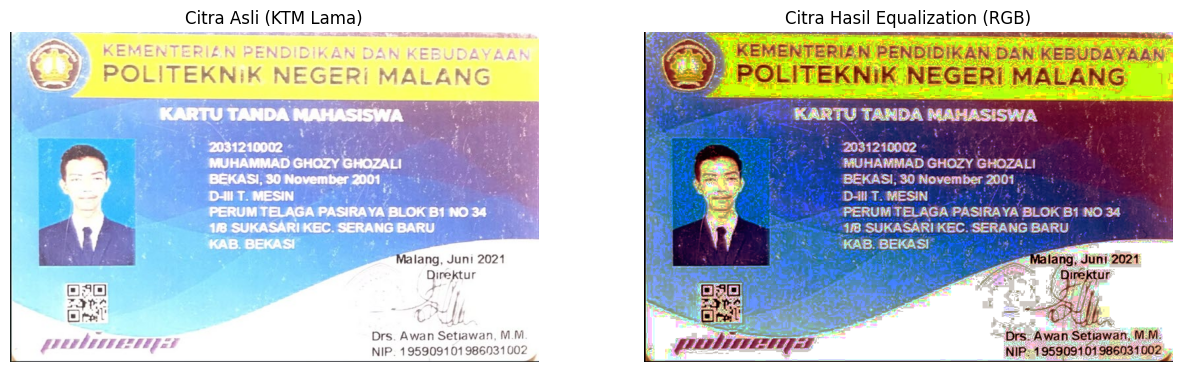

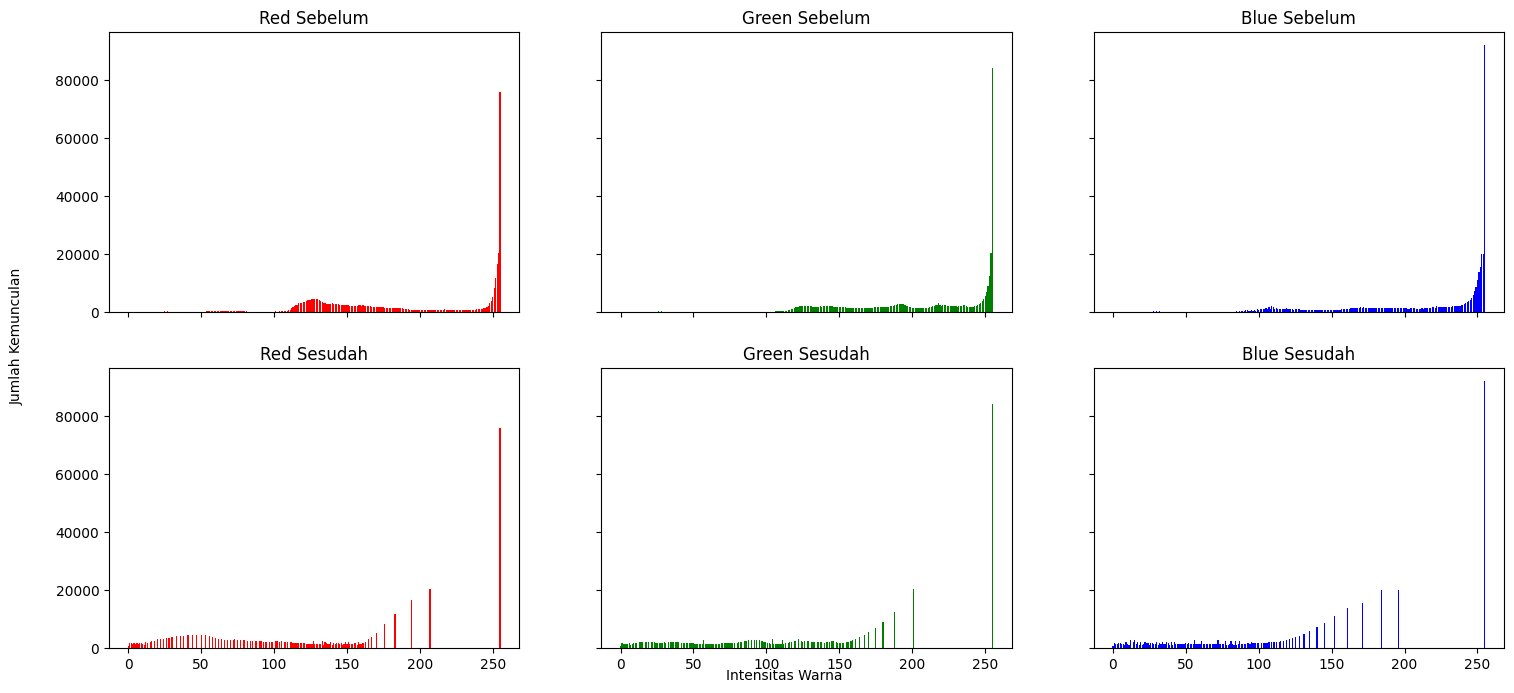

In [24]:
# Load gambar KTM lama (RGB)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/ktm_lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Split channel
r, g, b = cv.split(img)

# Histogram Equalization per channel
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Merge hasil equalization
img_eq = cv.merge((r_eq, g_eq, b_eq))

# Histogram sebelum dan sesudah
names = np.arange(256)
red   = cv.calcHist([img],[0],None,[256],[0,256]).flatten()
green = cv.calcHist([img],[1],None,[256],[0,256]).flatten()
blue  = cv.calcHist([img],[2],None,[256],[0,256]).flatten()

red_eq   = cv.calcHist([img_eq],[0],None,[256],[0,256]).flatten()
green_eq = cv.calcHist([img_eq],[1],None,[256],[0,256]).flatten()
blue_eq  = cv.calcHist([img_eq],[2],None,[256],[0,256]).flatten()

# Layout tampilan gambar
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,7))
ax1.imshow(img)
ax1.set_title("Citra Asli (KTM Lama)")
ax1.axis("off")

ax2.imshow(img_eq)
ax2.set_title("Citra Hasil Equalization (RGB)")
ax2.axis("off")
plt.show()

# Layout histogram RGB sebelum & sesudah
fig, axs = plt.subplots(2, 3, figsize=(18,8), sharex=True, sharey=True)
fig.text(0.07, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.07, 'Intensitas Warna', ha='center')

# Histogram sebelum
axs[0,0].bar(names, red, color='red');   axs[0,0].set_title("Red Sebelum")
axs[0,1].bar(names, green, color='green'); axs[0,1].set_title("Green Sebelum")
axs[0,2].bar(names, blue, color='blue');  axs[0,2].set_title("Blue Sebelum")

# Histogram sesudah
axs[1,0].bar(names, red_eq, color='red');   axs[1,0].set_title("Red Sesudah")
axs[1,1].bar(names, green_eq, color='green'); axs[1,1].set_title("Green Sesudah")
axs[1,2].bar(names, blue_eq, color='blue');  axs[1,2].set_title("Blue Sesudah")

plt.show()


**c. Analisis**

- Citra Asli (KTM Lama): tampak kusam, warna agak pudar, detail wajah & teks kurang jelas.
- Citra Equalized (RGB): kontras lebih tinggi, warna lebih tajam, detail teks/wajah lebih jelas.
- Histogram:
  - Sebelum → tiap channel menumpuk di area intensitas sempit.
  - Sesudah → tiap channel melebar di rentang [0–255].

## d-3 Tugas Praktikum Dithering

### 1.

Lakukanlah proses dithering Floyd and Steinberg seperti output berikut (tampilan image
awal, dan tampilan setelah dithering) berdasarkan flowchart di bagian bawah halaman
modul ini! (Gunakan gambar lena.jpg)

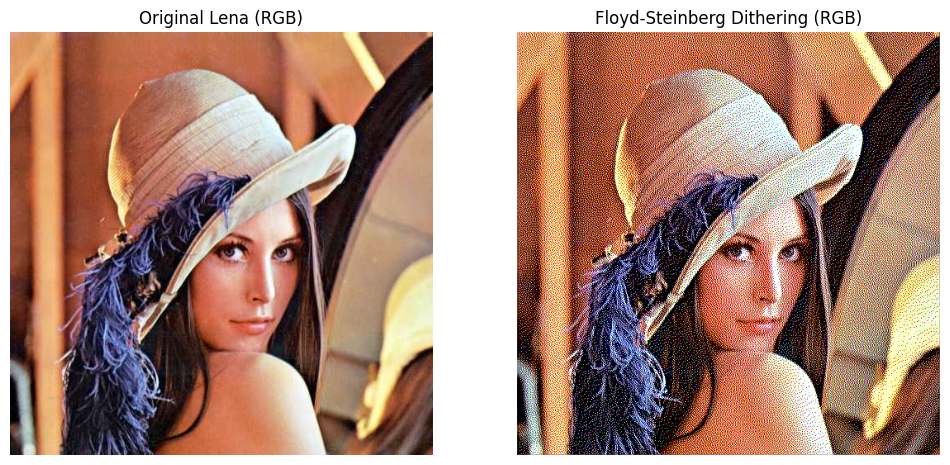

In [27]:
# Load gambar lena (RGB)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

h, w, c = img.shape
dithered = img.copy().astype(np.float32)

for y in range(h-1):
    for x in range(1, w-1):
        for channel in range(3):  # proses tiap channel RGB
            old_pixel = dithered[y, x, channel]
            new_pixel = 0 if old_pixel < 128 else 255
            dithered[y, x, channel] = new_pixel
            error = old_pixel - new_pixel

            # Floyd–Steinberg error diffusion
            dithered[y, x+1, channel]   += error * 7/16
            dithered[y+1, x-1, channel] += error * 3/16
            dithered[y+1, x, channel]   += error * 5/16
            dithered[y+1, x+1, channel] += error * 1/16

# Clipping biar tetap 0–255
dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# Tampilkan hasil
fig, axs = plt.subplots(1,2, figsize=(12,6))
axs[0].imshow(img)
axs[0].set_title("Original Lena (RGB)")
axs[0].axis("off")

axs[1].imshow(dithered)
axs[1].set_title("Floyd-Steinberg Dithering (RGB)")
axs[1].axis("off")

plt.show()


### 2

Menggunakan lena_lc.jpg rubah menjadi grey image, kemudian terapkan histogram
equalization sehingga terjadi perbaikan sebaran warna pada citra. Setelah itu dari hasil
histogram equalization implementasikan proses dithering Floyd and Steinberg sehingga
menampilkan gambar di bawah ini!

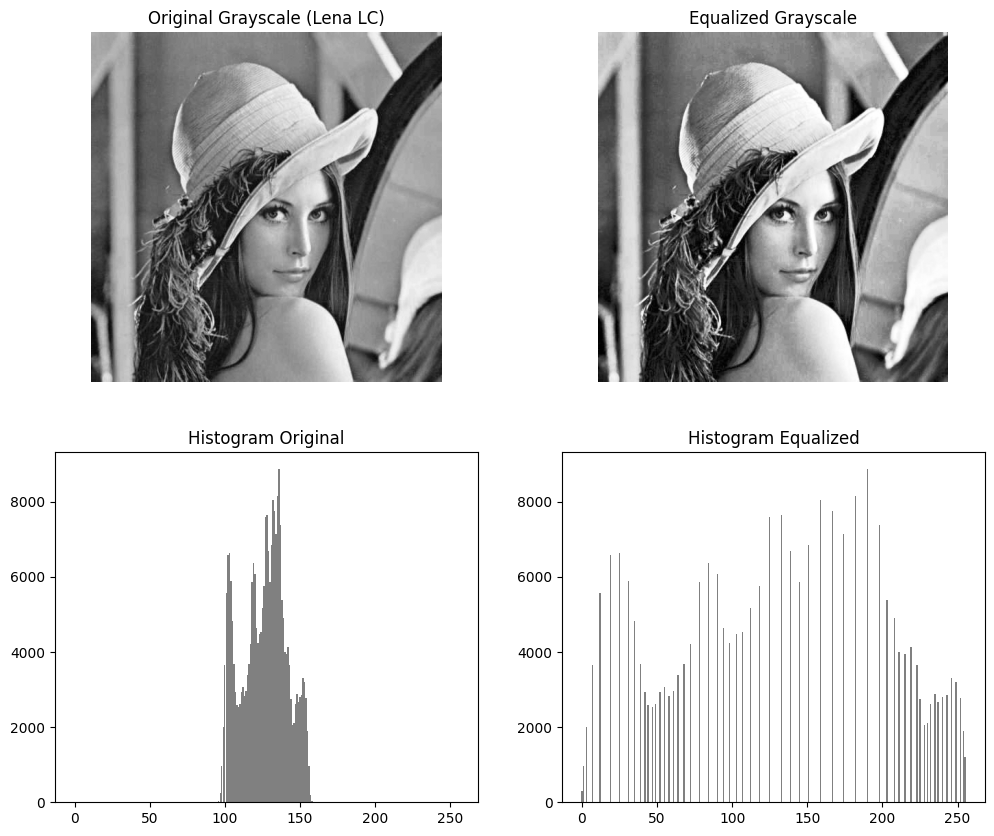

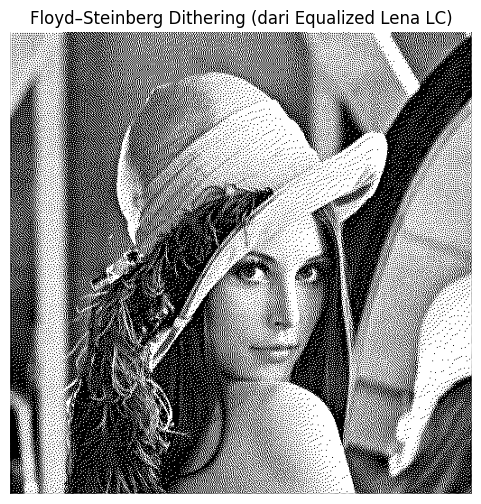

In [36]:
# --- Load gambar lena low contrast ---
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena_lc.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# --- Histogram Equalization ---
eq = cv.equalizeHist(gray)

# --- Floyd-Steinberg Dithering ---
h, w = eq.shape
dithered = eq.astype(np.float32).copy()

for y in range(h-1):
    for x in range(1, w-1):
        old_pixel = dithered[y, x]
        new_pixel = 0 if old_pixel < 128 else 255
        dithered[y, x] = new_pixel
        error = old_pixel - new_pixel

        # Distribusi error (Floyd–Steinberg kernel)
        dithered[y, x+1]   += error * 7/16
        dithered[y+1, x-1] += error * 3/16
        dithered[y+1, x]   += error * 5/16
        dithered[y+1, x+1] += error * 1/16

# Clipping ke 0–255
dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# --- Histogram sebelum & sesudah equalization ---
hist_orig = cv.calcHist([gray],[0],None,[256],[0,256]).flatten()
hist_eq   = cv.calcHist([eq],[0],None,[256],[0,256]).flatten()
names = np.arange(256)

# --- Layout hasil ---
fig, axs = plt.subplots(2,2, figsize=(12,10))

axs[0,0].imshow(gray, cmap='gray')
axs[0,0].set_title("Original Grayscale (Lena LC)")
axs[0,0].axis("off")

axs[0,1].imshow(eq, cmap='gray')
axs[0,1].set_title("Equalized Grayscale")
axs[0,1].axis("off")

axs[1,0].bar(names, hist_orig, color='gray')
axs[1,0].set_title("Histogram Original")

axs[1,1].bar(names, hist_eq, color='gray')
axs[1,1].set_title("Histogram Equalized")

plt.show()

# --- Tampilkan hasil dithering ---
plt.figure(figsize=(6,6))
plt.imshow(dithered, cmap='gray')
plt.title("Floyd–Steinberg Dithering (dari Equalized Lena LC)")
plt.axis("off")
plt.show()
